In [1]:
# stdlib
import argparse
import uuid
from concurrent.futures import ThreadPoolExecutor
import sys
import logging
from pathlib import Path

# numerical / compute
import numpy as np
import dask.array as da
import xarray as xr
import xgcm
import zarr

# distributed / IO
import dask
from dask.distributed import Client
import fsspec

# progress
import tqdm

# internal
import data_ingestion.get_raw_data as get_raw_data
import data_preprocessing.preproc_llc_core_data as preproc_llc_core_data
import data_preprocessing.weighted_coordinate_sampling as weighted_coordinate_sampling
import data_preprocessing.halo_mask as halo_mask

import dataset_creation.metadata as metadata
import dataset_creation.zarr_dataset as zarr_dataset
# import utils.native_gradient as ng
# import utils.physical_calculations as physical_calculations

# Constants --------------------------
TS_PER_HOUR = 144 # model cadence: 25 s → 144 steps/hr
MAX_ITER = 1_495_008
FIRST_WIND_RECORD_OFFSET = 10_368
LLC_FACES = range(13)

# url of our raw data - this may need to be an input in the future
endpoint_url = 'https://mghp.osn.xsede.org'


feature_channels_lazy = ["Eta", "Salt", "Theta", "U", "V", "W"] #,
feature_channels_computed = ["log_gradb"]

metadata_cols = [
    "id",
    "dataset_index",
    "native_grid",
    "center_grid_face",
    "center_grid_j",
    "center_grid_i",
    "center_lat",
    "center_lon",
    "target_km_res",
    "real_km_w",
    "real_km_h",
    "pre_interp_res",
    "log_grad_b_2_center",
    "time_snapshot"
]



In [3]:
# UNCHANGED - ------------------------------------------

def generate_filesystems(s3_endpoint):
    """
    Create asynchronous and synchronous S3 filesystems.

    The asynchronous filesystem is used for Zarr writes,
    while the synchronous filesystem is used for Parquet metadata.

    Parameters
    ----------
    s3_endpoint : str
        S3-compatible endpoint URL.

    Returns
    -------
    fs : fsspec.AbstractFileSystem
        Asynchronous S3 filesystem.
    fs_synch : fsspec.AbstractFileSystem
        Synchronous S3 filesystem.
    """

    fs = fsspec.filesystem(
        "s3",  #
        asynchronous=True,
        client_kwargs={
            "endpoint_url": s3_endpoint,

        },

        # These become botocore.client.Config(...)
        config_kwargs={
            "signature_version": "s3v4",
            "request_checksum_calculation": "when_required",
            "s3": {
                "addressing_style": "path",
                "payload_signing_enabled": False,
                "use_accelerate_endpoint": False,
                "use_dualstack_endpoint": False,
            },
        },
    )

    fs_synch = fsspec.filesystem(
        "s3",  #
        asynchronous=False,
        client_kwargs={
            "endpoint_url": s3_endpoint,

        },

        # These become botocore.client.Config(...)
        config_kwargs={
            "signature_version": "s3v4",
            "request_checksum_calculation": "when_required",
            "s3": {
                "addressing_style": "path",
                "payload_signing_enabled": False,
                "use_accelerate_endpoint": False,
                "use_dualstack_endpoint": False,
            },
        },
    )

    return fs, fs_synch

def generate_metadata_writer(bucket, folder, run_id, fs_synch):
    meda_data_folder_path = "s3://" + bucket + folder + run_id + f"metadata/"
    return metadata.MetadataWriter(meda_data_folder_path, flush_every=10000, fs = fs_synch)



def generate_land_face_masks(ds_grid, target_km_res):
    """
    Construct a composite sampling mask for the LLC native grid. These are the unchanging masks, so not ice.

    The mask excludes:
      - land points (via hFacC)
      - grid-face perimeter cells
    and applies a halo buffer based on the target physical resolution to land and face perimeter cells.

    Parameters
    ----------
    ds_grid : xarray.Dataset
        LLC grid dataset containing metric terms.
    target_km_res : float
        Target physical resolution (km) used to define halo width.

    Returns
    -------
    xarray.DataArray
        Boolean mask indicating valid sampling locations.
        True = sample
        False = mask
    """

    halo_km = target_km_res  # buffer to account for mean usage

    DXC = ds_grid["dxC"].persist()
    DYC = ds_grid["dyC"].persist()
    land_mask = (ds_grid.hFacC == 0).persist()

    halo_land_mask = halo_mask.llc_halo_mask(
        mask=land_mask,
        dxC=DXC,
        dyC=DYC,
        halo_km=halo_km
    )

    faces_perimeter_mask = xr.zeros_like(ds_grid.XC).astype(bool)
    faces_perimeter_mask.loc[dict(j=0)] = True
    faces_perimeter_mask.loc[dict(j=(faces_perimeter_mask.coords.sizes["j"] - 1))] = True
    faces_perimeter_mask.loc[dict(i=0)] = True
    faces_perimeter_mask.loc[dict(i=(faces_perimeter_mask.coords.sizes["i"] - 1))] = True

    halo_faces_perimeter_mask = halo_mask.llc_halo_mask(
        mask=faces_perimeter_mask,
        dxC=DXC,
        dyC=DYC,
        halo_km=halo_km
    )

    merged_mask = halo_land_mask & halo_faces_perimeter_mask

    return merged_mask

def set_up_grid_data_and_masks(target_km_res):
    logging.info("Fetching grid file")
    co = get_raw_data.get_remote_gridfile(endpoint_url)
    ds_grid = preproc_llc_core_data.process_llc4320_grid(co)

    logging.info("Calculating land and face masks")
    land_face_mask = generate_land_face_masks(ds_grid, target_km_res)

    return ds_grid, land_face_mask


def calculate_iterations_for_llc(sampling_step, start_record, timestep_hours):
    # Calculate iterations based on input
    iter_step = sampling_step * TS_PER_HOUR  # iteration Δ between samples
    start_iter = 10368 + start_record * TS_PER_HOUR

    if (timestep_hours is None):
        end_iter = 1495008  # to the end of data
    else:
        end_iter = start_iter + timestep_hours * TS_PER_HOUR

    return np.arange(start_iter, end_iter, iter_step)




In [4]:
logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
        ],
        force=True,
    )

In [5]:
# ARGS =---------------------------

# 4 samples, 1 from each of 4 consecutive weeks

# temporal options ------
#timestep_hours = "8064" # 1 year
timestep_hours = 168
#timestep_hours = "168"

sampling_step = 168
#sampling_step = "2016" # 3month

start_record = 1180         # first valid wind/forcing record begins ~1180, This is also the default start of the script

# spatial options ------
target_km_res = 150         # km resolution of our patches w and h
down_sample_res = 64        # pixel resolution of our patches w and h
sample_points_per_snapshot = 100   # how many patches to take from each snapshot
bias_to_high_gradients = 2  # see documentation on sampling

# s3 output config ------
# Note: include trailing "/" please
bucket = "llc/"
folder = "native_grid_dbof_training_data/"
run_id = "script_test_fast_01/"   # should be unique for each instance of dbof you wish to create, it is just a folder in s3

s3_endpoint = "https://s3-west.nrp-nautilus.io"

In [6]:
# MAIN part 1 ------------------------- UNCHANGED

# Set concurrency for zarr ds writes
zarr.config.set({'async.concurrency': 128})

# set up dask distributed client
dask_client = Client()  # default: uses all local cores
logging.info(f"Dask Client {dask_client}")


iter_range = calculate_iterations_for_llc(sampling_step, start_record, timestep_hours)
logging.info(f"Processing: {iter_range} time snapshots")


# Set up meta and zarr data writers
fs, fs_synch = generate_filesystems(s3_endpoint)
metadata_writer = generate_metadata_writer(bucket, folder, run_id, fs_synch)


# Zarr Dataset
dataset_name = f"dataset.zarr"
zarr_ds = zarr_dataset.ZarrDataset(bucket, folder, run_id, dataset_name, fs=fs,
                                   feature_channels=feature_channels_lazy+feature_channels_computed,
                                   down_sample_res=down_sample_res)

logging.info(f"Zarr dataset created.")

# Get data grid once
ds_grid, land_face_mask = set_up_grid_data_and_masks(target_km_res)
grid = xgcm.Grid(ds_grid, periodic=False)

# for it in tqdm.tqdm(iter_range):

it = iter_range[0] # ONE ITERATION

2026-01-16 12:04:53,369 | INFO | root | Dask Client <Client: 'tcp://127.0.0.1:57644' processes=4 threads=12, memory=31.10 GiB>
2026-01-16 12:04:53,370 | INFO | root | Processing: [180288] time snapshots
2026-01-16 12:04:53,379 | INFO | aiobotocore.credentials | Found credentials in shared credentials file: ~/.aws/credentials
2026-01-16 12:04:55,527 | INFO | root | Zarr dataset created.
2026-01-16 12:04:55,527 | INFO | root | Fetching grid file
2026-01-16 12:05:03,483 | INFO | root | Calculating land and face masks


In [7]:
# 1 iteration of MAIN FOR LOOP AND process_time_snapshot() UNCHANGED

ds = get_raw_data.get_remote_llc_data(endpoint_url, it, LLC_FACES)
ds_merge = preproc_llc_core_data.process_llc4320(ds, ds_grid)

logging.info(f"Data loaded for iteration: {it}")

# NOTE The ordering of the following steps matters

# Calculate Ice Mask
logging.info(f"Calculating ice mask")
ice_mask = ~(ds_merge.Theta <= 0.0)
ice_mask_np = ice_mask.values
merged_mask = ice_mask_np & land_face_mask


ds_merge, log_gradb = dbof_front_training_utils.calculate_gradients(ds_merge, grid)


Opening 13 Kerchunk JSON files...
Parsing JSON metadata into Python dicts...
Creating lazy xarray datasets...
Computing delayed datasets...
Combining datasets by coordinates...
Dataset combined successfully.
2026-01-16 12:08:55,003 | INFO | root | Data loaded for iteration: 180288
2026-01-16 12:08:55,003 | INFO | root | Calculating ice mask


In [8]:
# find indices with mask
logging.info(f"Sampling patch center points")

# todo this should be updated to take in a numpy array since we compute loggradb later anyway
indices = weighted_coordinate_sampling.weighted_sample_on_grid(sample_points_per_snapshot, bias_to_high_gradients, log_gradb, merged_mask)

# Move non tracer values to tracer points. This allows us to stack images for our final patches.
ds_merge["V"] = grid.interp(ds_merge["V"], 'Y', boundary='fill')
ds_merge["U"] = grid.interp(ds_merge["U"], 'X', boundary='fill')



2026-01-16 12:09:11,100 | INFO | root | Sampling patch center points


C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 235.69 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:3370: UserWarning: Sending large graph of size 519.82 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


# Updates to creation logic below

In [9]:
# def create_image_patch(ds, channels, patch):
#     channels_array = []
#     for channel in channels:
#         feature = ds[channel].isel(
#             face=patch["face"],
#             j=slice(patch["j_start"], patch["j_end"] + 1),
#             i=slice(patch["i_start"], patch["i_end"] + 1))
#
#         # Get the underlying dask array (or numpy array)
#         # channels_array.append(feature.data)
#         channels_array.append(feature.values.astype('float32'))
#
#     # Stack as dask array - this remains lazy
#     # img = da.stack(channels_array, axis=0).astype('float32')  # (C, H, W)
#     img = np.stack(channels_array, axis=0)
#
#     return img





# # this approach is around 1.5 mins
# def create_image_patches_batch_as_tensors(ds, channels, patches, scheduler='threads'):
#     # Create lazy dask arrays for each patch
#     patch_arrays = [create_image_patch(ds, channels, patch) for patch in patches]
#
#     # Compute all at once in parallel
#     computed_arrays = dask.compute(*patch_arrays, scheduler=scheduler)
#
#     # return computed_arrays
#
#     # Convert to PyTorch tensors
#     tensors = [torch.from_numpy(arr) for arr in computed_arrays]
#
#     return tensors


In [10]:
# from dask import delayed
#
# @delayed
# def downsample_image_and_prepare_metadata(patch_data, image, patch, down_sample_res):
#     index = patch_data["index"]
#
#     patch_metadata = dict.fromkeys(metadata_cols)
#     patch_metadata["id"] = str(uuid.uuid4())
#     patch_metadata["native_grid"] = "LLC4320"
#     patch_metadata["center_grid_face"] = index[0]
#     patch_metadata["center_grid_j"] = index[1]
#     patch_metadata["center_grid_i"] = index[2]
#     patch_metadata["target_km_res"] = target_km_res
#     patch_metadata["center_lat"] = patch_data["center_lat"]
#     patch_metadata["center_lon"] = patch_data["center_lon"]
#
#     patch_metadata["log_grad_b_2_center"] = patch_data["log_grad_b_2_center"]
#
#     patch_metadata["time_snapshot"] = patch_data["time_snapshot"]
#
#     patch_metadata["real_km_w"] = patch["real_km_w"]
#     patch_metadata["real_km_h"] = patch["real_km_h"]
#
#     # img_patch = patch_data["img_patch"]
#     img_patch = image
#
#     patch_metadata["pre_interp_res"] = img_patch[0].shape
#
#     data_sample = spatial_patches.downsample_image(img_patch, target_dim=down_sample_res)
#
#
#     # todo this should be safe here but test
#     image_id = zarr_ds.append_image(data_sample)
#     patch_metadata["dataset_index"] = image_id
#     metadata_writer.add(patch_metadata)
#
#     return data_sample, patch_metadata

In [11]:
# import torch
#
#
# def create_image_patch_lazy(ds, channels, patch):
#     channels_array = []
#
#     for channel in channels:
#         feature = ds[channel].isel(
#             face=patch["face"],
#             j=slice(patch["j_start"], patch["j_end"] + 1),
#             i=slice(patch["i_start"], patch["i_end"] + 1),
#         )
#         channels_array.append(feature.data)
#
#     # Stack lazily (Dask only)
#     img = da.stack(channels_array, axis=0).astype("float32")  # (C, H, W)
#
#     return img
#
#
# def create_image_patch_numpy(array, patch):
#     log_slice = array[
#             patch["face"],
#             patch["j_start"] : patch["j_end"] + 1,
#             patch["i_start"] : patch["i_end"] + 1,
#         ].astype("float32")
#
#     return log_slice
#
#
# # todo future proof for more dask arrays like loggradb
# # todo quadruple check that dask respects order
# def create_image_patches_batch_as_tensors_dask(ds, log_gradb_np, lazy_channels, patches, scheduler='threads'):
#
#     # 1. Build lazy dask arrays (DS channels only)
#     patch_arrays = [
#         create_image_patch_lazy(ds, lazy_channels, patch)
#         for patch in patches
#     ]
#
#     # 2. Compute in parallel
#     computed_arrays = dask.compute(*patch_arrays, scheduler=scheduler)
#
#     tensors = []
#     # 3. Append log_gradb (NumPy) per patch
#     for arr, patch in zip(computed_arrays, patches):
#
#         log_slice = create_image_patch_numpy(log_gradb_np, patch)
#
#         log_slice = np.expand_dims(log_slice, axis=0)
#         img = np.concatenate((arr, log_slice), axis=0)
#         tensors.append(torch.from_numpy(img))
#
#     return tensors


In [12]:
# # not parallelized.
# def extract_patch_extents(index, ds_merge, log_gradb_np, target_km_res):
#
#     """Extract all needed data from ds_merge for one patch"""
#     patch_meta_data = {}
#     patch_meta_data["index"] = index
#     patch_meta_data["center_lat"] = ds_merge.YC[index].values.item()
#     patch_meta_data["center_lon"] = ds_merge.XC[index].values.item()
#
#     patch_meta_data["log_grad_b_2_center"] = log_gradb_np[index]
#
#     patch_meta_data["time_snapshot"] = np.datetime64(ds_merge.time.item(), 'ns')
#
#     patch = spatial_patches.get_lat_lon_extents_of_patch(index, ds_merge, target_km_res)
#
#     if patch is None:
#         return None, None
#
#     return patch, patch_meta_data

In [13]:
# # computed dask_arrays must be numpy
# def run_patch_creation(zarr_ds, metadata_writer, down_sample_res,
#                  indices, ds_merge, log_gradb_np, target_km_res, feature_channels_lazy):
#
#
#     # Extract all patch data extents ---------------------------------------------------------
#     patch_meta_data_list = []
#     patches = []
#     logging.info(f"Starting patch extents creation") # this takes about 1.5s per patch
#
#     # currently there are issues with computing ds_merge down stream that break parallization code
#     for index in indices:
#         patch, patch_meta_data = extract_patch_extents(index, ds_merge, log_gradb_np, target_km_res)
#
#         if patch_meta_data is not None:
#             patch_meta_data_list.append(patch_meta_data)
#             patches.append(patch)
#
#
#     # Create images of patches ----------------------------------------------------------------------
#     logging.info("Starting batched image creation")
#     images = create_image_patches_batch_as_tensors_dask(ds_merge, log_gradb_np, feature_channels_lazy, patches, scheduler='threads')
#
#
#     # Downsample images and get metadata ----------------------------------------------------
#     logging.info("Downsampling Images")
#     tasks = []
#     for pd, image, patch in zip(patch_meta_data_list, images, patches):
#         tasks.append(downsample_image_and_prepare_metadata(pd, image, patch, down_sample_res))
#
#     dask.compute(*tasks, scheduler='threads')
#
#     # # Write results sequentially -------------------
#     # logging.info(f"write results")
#     # for data_sample, patch_metadata in results:
#     #     image_id = zarr_ds.append_image(data_sample)
#     #     patch_metadata["dataset_index"] = image_id
#     #     metadata_writer.add(patch_metadata)
#
#     return images


In [14]:
#compute loggradb todo add to main
log_gradb_np = log_gradb.values

In [16]:
# create our patches

zarr_ds.grow_array(len(indices))

from dataset_creation import dbof_front_training_utils


images = dbof_front_training_utils.run_patch_creation(zarr_ds, metadata_writer, down_sample_res,
                 indices, ds_merge, log_gradb_np, target_km_res, feature_channels_lazy, metadata_cols)

metadata_writer.close()


2026-01-16 12:23:22,006 | INFO | root | Starting patch extents creation


KeyboardInterrupt: 

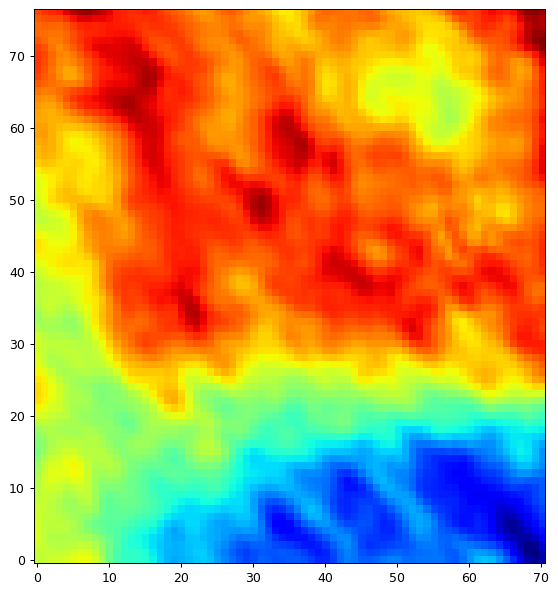

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8), dpi= 90)
plt.imshow(images[0][0],origin='lower',cmap='jet')

# plt.figure(figsize=(8,8), dpi= 90)
# plt.imshow(zarr_ds.root["images"][1][1],origin='lower',cmap='jet')

In [18]:
import fsspec
import pandas as pd

fs_synch = fsspec.filesystem(
    "s3", #
    asynchronous=False,
    client_kwargs={
        "endpoint_url": s3_endpoint,

    },

    # These become botocore.client.Config(...)
    config_kwargs={
        "signature_version": "s3v4",
        "request_checksum_calculation": "when_required",
        "s3": {
            "addressing_style": "path",
            "payload_signing_enabled": False,
            "use_accelerate_endpoint": False,
            "use_dualstack_endpoint": False,
        },
    },
)

fs = fsspec.filesystem(
        "s3",  #
        asynchronous=True,
        client_kwargs={
            "endpoint_url": s3_endpoint,

        },

        # These become botocore.client.Config(...)
        config_kwargs={
            "signature_version": "s3v4",
            "request_checksum_calculation": "when_required",
            "s3": {
                "addressing_style": "path",
                "payload_signing_enabled": False,
                "use_accelerate_endpoint": False,
                "use_dualstack_endpoint": False,
            },
        },
    )

In [20]:
print(run_id)

script_test_fast_01/


In [21]:
files = fs_synch.glob(
    f"llc/native_grid_dbof_training_data/{run_id}metadata/*.parquet"
)

meta_df = pd.read_parquet(files, filesystem=fs_synch)


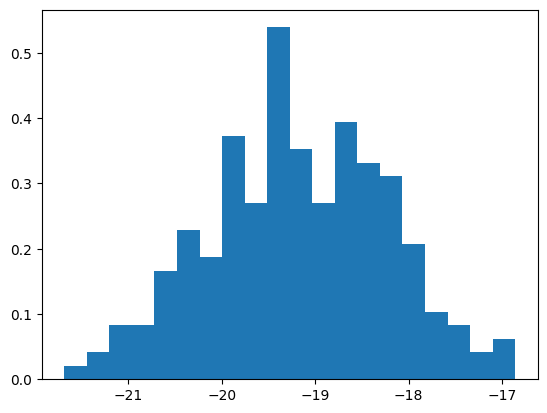

In [22]:
hist, edges = np.histogram(meta_df["log_grad_b_2_center"], bins=20, density=True)

plt.bar(
    edges[:-1],
    hist,
    width=np.diff(edges),
    align="edge"
)

plt.show()

In [23]:
reader = zarr_dataset.ZarrDatasetReader(
    bucket=bucket,
    folder=folder,
    run_id=run_id,
    dataset_name="dataset.zarr",
    fs=fs
)

img, img_id = reader.get_image(10)

imgs, ids = reader.get_images([0,1,2,3,4,5,6,7,8,9,10])

In [24]:
print(reader.num_images)

400


In [26]:
for img in imgs:
    plt.figure(figsize=(8,8), dpi= 90)
    plt.imshow(img[0],origin='lower',cmap='jet')


IndexError: index 350 is out of bounds for axis 0 with size 7

<Figure size 720x720 with 0 Axes>

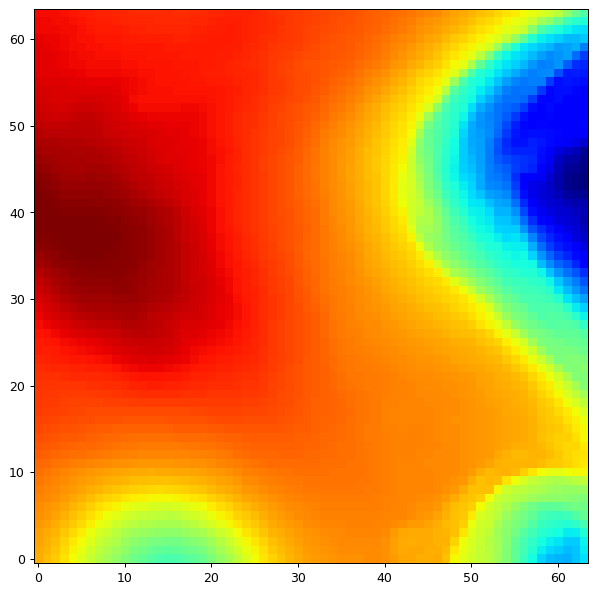

In [28]:
img, img_id = reader.get_image(250)
plt.figure(figsize=(8,8), dpi= 90)
plt.imshow(img[0],origin='lower',cmap='jet')

In [167]:
print(float(ds_merge.YC[indices[0]].compute()))
print(ds_merge.XC[indices[0]].values.item())
(log_gradb[indices[0]].values.item())
print(np.datetime64(ds_merge.time.item(), 'ns'))

# Note lat lon extents - 1s create img - 10s writing - 1s

# patch = spatial_patches.get_lat_lon_extents_of_patch(indices[0], ds_merge, target_km_res) #1s
#
# spatial_patches.create_image_patch(ds_merge, feature_channels, patch) #  10s
#
# data  = extract_patch_data(indices[0], ds_merge, target_km_res)
# # print(patch)
#
# data_sample = process_patch_data(data, down_sample_res).compute() # 1s
#
# zarr_ds.grow_array(1)
# image_id = zarr_ds.append_image(data_sample[0]) # 1s
#
# metadata_writer.add(patch_metadata)

2026-01-16 09:05:56,841 | ERROR | asyncio | Task exception was never retrieved
future: <Task finished name='Task-2329538' coro=<Client._gather.<locals>.wait() done, defined at C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py:2384> exception=AllExit()>
Traceback (most recent call last):
  File "C:\Users\Jake Tallman\PycharmProjects\dbof-in-native-grid\.venv1\Lib\site-packages\distributed\client.py", line 2393, in wait
    raise AllExit()
distributed.client.AllExit


KeyboardInterrupt: 